In [1]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images

import numpy as np
import random
from matplotlib import pyplot as plt
import random

# Global variable - Fusion360

In [2]:
def load_saved_tensor(filepath):
    t = torch.load(filepath)
    
    return t

def load_json(filepath):
    with open(filepath, 'r') as fp:
        j = json.load(fp)   # .shape[0]=141245
    
    return j

In [3]:
rec_seq_path = "model_outputs/rec_seq_0823_110503_last.pt"
ori_seq_path = "model_outputs/ori_seq_0823_110503_last.pt"

rec_seq = load_saved_tensor(rec_seq_path)   # [10377, 10, 512]
ori_seq = load_saved_tensor(ori_seq_path)   # [10377, 10, 512]

all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = load_saved_tensor(all_emb_path)   # [141245, 512]

all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
all_md = load_json(all_md_path)   # .shape[0]=141245  

In [4]:
def compute_aid_to_part_indice_map():
    the_map = dict()
    assert len(all_md) == all_emb.shape[0]
    for idx, md in enumerate(all_md):
        aid = '_'.join(md.split('_')[1:3])
        if aid in the_map:
            the_map[aid].append(idx)
        else:
            the_map[aid] = []
            the_map[aid].append(idx)
    
    return the_map

aid_to_part_indice_map = compute_aid_to_part_indice_map()   # 8146: # assemblies got successfully processed/rendered

print(f'Total number of assemblies: {len(aid_to_part_indice_map)}')

Total number of assemblies: 8146


In [5]:
def compute_md_to_idx_map():
    the_map = dict()
    for idx, md in enumerate(all_md):
        the_map[md] = idx
    
    return the_map

md_to_idx_map = compute_md_to_idx_map()
print(f'Number of parts: {len(md_to_idx_map)}')

Number of parts: 141245


In [6]:
all_part_graph_path = './processed_data/part_graphs_dim=5.json'
all_part_graph = load_json(all_part_graph_path)
valid_aid_list = list(all_part_graph.keys())   # 5462: # assemblies having contact info, also # assemblies in the part graph
print(f'Number of assemblies having contact information / included in the part graph: {len(valid_aid_list)}')

Number of assemblies having contact information / included in the part graph: 5462


# Global variable - CLIP query

In [70]:
clip_query_seq_path = "model_outputs/mech_query_seq_0801_161839_last.pt"
clip_query_seq = load_saved_tensor(clip_query_seq_path)
print(f'Number of clip text queries: {clip_query_seq.shape[0]}')

mech_part_names_path = './processed_data/clip_mech_query_metadata.json'
mech_part_names = load_json(mech_part_names_path)
assert clip_query_seq.shape[0] == len(mech_part_names['mech_name'])

Number of clip text queries: 26


# Global variable - ABC

In [7]:
abc_query_seq_path = "model_outputs/abc_query_seq_0801_161839_last.pt"
abc_query_seq = load_saved_tensor(abc_query_seq_path)
print(f'Number of abc image queries: {abc_query_seq.shape[0]}')

abc_md_path = './processed_data/abc_emb_idx_filtered.json'
abc_md = load_json(abc_md_path)
assert abc_query_seq.shape[0] == len(abc_md)

Number of abc image queries: 423


# Compute norm

In [7]:
def compute_norm(seq):
    all_norm_list = []
    for s in seq:
        # seq: [10, 512]
        norm_list = []
        for emb in s:
            # emb: [512]
            norm_list.append(LA.norm(emb).item())
        all_norm_list.append(norm_list)
    
    return all_norm_list

def compute_norm_clip_emb(seq):
    all_norm_list = []
    for emb in seq:
        all_norm_list.append(LA.norm(emb).item())
    
    return all_norm_list

In [8]:
# # For rec_seq
# all_rec_norm_list = []
# for seq in rec_seq:
#     # seq: [10, 512]
#     norm_list = []
#     for emb in seq:
#         # emb: [512]
#         norm_list.append(LA.norm(emb).item())
#     all_rec_norm_list.append(norm_list)

all_rec_norm_list = compute_norm(rec_seq)

# # For ori_seq
# all_ori_norm_list = []
# for seq in ori_seq:
#     # seq: [10, 512]
#     norm_list = []
#     for emb in seq:
#         # emb: [512]
#         norm_list.append(LA.norm(emb).item())
#     all_ori_norm_list.append(norm_list)

all_ori_norm_list = compute_norm(ori_seq)

assert len(all_rec_norm_list) == len(all_ori_norm_list)

In [9]:
# For query_seq
all_query_norm_list = compute_norm(abc_query_seq)

In [163]:
print(len(all_query_norm_list))

423


# Find the closest part

In [9]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

## 1. Find part in the entire part embedding space

In [10]:
import torch.nn.functional as F

In [11]:
def find_closest(emb, indices=list(range(len(all_emb)))):
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   #[141245]
    indices = torch.LongTensor(indices)
    min_val = torch.min(torch.index_select(dist, 0, indices)).item()
#     print(f'min: {dist[indices].min()}, max: {dist[indices].max()}')
#     idx = dist.argmin()   # If there are multiple minimal values then the indices of the first minimal value are returned.
    idx_tuple = (dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
    for idx in idx_tuple:
        if idx in indices:
#             print(F.mse_loss(emb, all_emb[idx], reduction='sum'))
            return idx.item(), dist[idx].item()
    
    idx = idx_tuple[0]
#     print(F.mse_loss(emb, all_emb[idx], reduction='sum'))
    return idx.item(), dist[idx].item()

def decode_seq_1(in_seq, head_number, all_norm_list):
    all_closest_emb_list = []
    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):
        closest_emb_list = []
        for j, emb in enumerate(seq):
            if all_norm_list[i][j] < eps:
                break
            closest_emb_idx, closest_dist = find_closest(emb)
            print(f'Closest distance: {closest_dist}')
            closest_emb_list.append(closest_emb_idx)
        all_closest_emb_list.append(closest_emb_list)
    
    return all_closest_emb_list

def decode_seq_clip_emb_1(in_seq, head_number, all_norm_list):
    all_closest_emb_list = []
    for i, emb in tqdm(enumerate(in_seq[:head_number, :])):
        closest_emb_list = []
        if all_norm_list[i] < eps:
            break
        closest_emb_idx, closest_dist = find_closest(emb)
        print(f'Closest distance: {closest_dist}')
        closest_emb_list.append(closest_emb_idx)
        all_closest_emb_list.append(closest_emb_list)
    
    return all_closest_emb_list

In [12]:
# all_rec_closest_emb_list = []
# for i, seq in tqdm(enumerate(rec_seq[:20, :, :])):
#     closest_emb_list = []
#     for j, rec_emb in enumerate(seq):
#         if all_rec_norm_list[i][j] < eps:
#             break
#         closest_emb_idx, closest_dist = find_closest(rec_emb)
#         print(f'Closest distance: {closest_dist}')
#         closest_emb_list.append(closest_emb_idx)
#     all_rec_closest_emb_list.append(closest_emb_list)

all_rec_closest_emb_list = decode_seq_1(rec_seq, 100, all_rec_norm_list)

0it [00:00, ?it/s]

Closest distance: 0.1267172396183014
Closest distance: 0.1342684030532837
Closest distance: 0.08732321858406067
Closest distance: 0.15853168070316315


1it [00:00,  1.40it/s]

Closest distance: 0.1874164491891861
Closest distance: 0.2015632688999176
Closest distance: 0.07411561161279678
Closest distance: 0.09799449890851974


2it [00:01,  2.02it/s]

...

Closest distance: 0.1840600073337555
Closest distance: 0.06668472290039062
Closest distance: 0.1581849306821823
Closest distance: 0.12363829463720322


99it [00:35,  2.03it/s]

Closest distance: 0.11975451558828354
Closest distance: 0.1563514918088913
Closest distance: 0.05351231247186661
Closest distance: 0.12752963602542877


100it [00:36,  2.75it/s]

Closest distance: 0.15074945986270905


In [13]:
# all_ori_closest_emb_list = []
# for i, seq in tqdm(enumerate(ori_seq[:20, :, :])):
#     closest_emb_list = []
#     for j, ori_emb in enumerate(seq):
#         if all_ori_norm_list[i][j] < eps:
#             break
#         closest_emb_idx, _ = find_closest(ori_emb)
#         closest_emb_list.append(closest_emb_idx)
#     all_ori_closest_emb_list.append(closest_emb_list)

all_ori_closest_emb_list = decode_seq_1(ori_seq, 100, all_ori_norm_list)

0it [00:00, ?it/s]

Closest distance: 0.0


1it [00:00,  4.33it/s]

Closest distance: 0.0
Closest distance: 0.0


2it [00:00,  4.27it/s]

...

Closest distance: 0.0
Closest distance: 0.0
Closest distance: 0.0
Closest distance: 0.0
Closest distance: 0.0


99it [00:44,  1.95it/s]

Closest distance: 0.0
Closest distance: 0.0


100it [00:44,  2.25it/s]

Closest distance: 0.0


In [13]:
# all_query_closest_emb_list = []
# for i, seq in tqdm(enumerate(query_seq[:100])):
#     closest_emb_list = []
#     for j, rec_emb in enumerate(seq):
#         if all_query_norm_list[i][j] < eps:
#             break
#         closest_emb_idx, closest_dist = find_closest(rec_emb)
#         print(f'Closest distance: {closest_dist}')
#         closest_emb_list.append(closest_emb_idx)
#     all_query_closest_emb_list.append(closest_emb_list)

all_query_closest_emb_list = decode_seq_1(abc_query_seq.cpu(), 50, all_query_norm_list)

0it [00:00, ?it/s]

Closest distance: 0.14287705719470978
Closest distance: 0.22945648431777954
Closest distance: 0.201816588640213


1it [00:00,  2.84it/s]

Closest distance: 0.1627470701932907
Closest distance: 0.11414775997400284
Closest distance: 0.090901218354702


2it [00:00,  3.51it/s]

...

Closest distance: 0.12936578691005707
Closest distance: 0.10624493658542633
Closest distance: 0.17004966735839844


48it [00:11,  4.53it/s]

Closest distance: 0.20749031007289886
Closest distance: 0.16100801527500153
Closest distance: 0.18944530189037323


50it [00:12,  4.07it/s]

Closest distance: 0.12169527262449265
Closest distance: 0.19390837848186493
Closest distance: 0.15957011282444


In [17]:
all_rec_closest_emb_list[:10]

[[119509, 75631],
 [137329, 115511, 130811],
 [15110, 106573, 130501, 130501],
 [88949, 106573, 130501],
 [123429, 121837, 126283],
 [56399, 82528, 134922],
 [93939, 11262, 1998, 130500],
 [105459, 95368, 50917, 76276, 30221, 15631, 136845],
 [37507, 31621, 2497, 2497, 18976, 106784, 127607, 48642],
 [96149, 19151]]

In [18]:
all_ori_closest_emb_list

[[129259, 129260],
 [129260, 129259],
 [96139, 96143, 96146, 96148, 96149],
 [96140, 96147, 96142, 96143, 96151, 96148, 96149, 96141],
 [96141, 96143, 96140],
 [96142, 96143, 96140],
 [96143, 96147, 96142, 96150, 96151, 96152, 96146, 96139, 96148, 96149],
 [96146, 96143, 96139],
 [96147, 96143, 96140],
 [96148, 96143, 96139, 96140]]

## 2. Find part in the same assembly (top-k)

In [147]:
def find_topk_closest(emb, k=10):
    
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   # [141245]
    sorted_dist, indices = torch.sort(dist)
    topk_indices = indices[:k]   # The k closest (out of all) part embedding's indices
    
    return topk_indices

In [148]:
def find_part(emb, ind):

    img_name = all_md[ind]
    aid = '_'.join(img_name.split('_')[1:3])
    constraint_indices = aid_to_part_indice_map[aid]
    part_idx, _ = find_closest(emb, constraint_indices)
    
    return part_idx
    

In [149]:
def decode_seq_2(in_seq, head_number, all_norm_list):
    
    all_decoded_seq_list = []   # list of list of list

    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):   # for each reconstructed part embedding sequence
        candi_part_indices = find_topk_closest(seq[0])   # find topk closest part embedding of the central part embedding
        decoded_seq_list = []   # list of list
        for candi_part_index in candi_part_indices:
            decoded_seq = []   # store the decoded seq constrained by candi_part_index
            decoded_seq.append(candi_part_index.item())
            for j, rec_emb in enumerate(seq):   # for each neighbouring part embedding
                if j==0:   # Skip decoding the first(central) part embedding
                    continue

                if all_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                    break

                part_idx = find_part(rec_emb, candi_part_index)   # find the closest part index constrained by candi_part_index
                decoded_seq.append(part_idx)

            decoded_seq_list.append(decoded_seq)   # add the decoded_seq

        all_decoded_seq_list.append(decoded_seq_list)
    
    return all_decoded_seq_list

In [ ]:
# all_decoded_seq_list = []   # list of list of list

# for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):   # for each reconstructed part embedding sequence
#     candi_part_indices = find_topk_closest(seq[0])   # find topk closest part embedding of the central part embedding
#     decoded_seq_list = []   # list of list
#     for candi_part_index in candi_part_indices:
#         decoded_seq = []   # store the decoded seq constrained by candi_part_index
#         decoded_seq.append(candi_part_index.item())
#         for j, rec_emb in enumerate(seq):   # for each neighbouring part embedding
#             if j==0:   # Skip decoding the first(central) part embedding
#                 continue
            
#             if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
#                 break
            
#             part_idx = find_part(rec_emb, candi_part_index)   # find the closest part index constrained by candi_part_index
#             decoded_seq.append(part_idx)
            
#         decoded_seq_list.append(decoded_seq)   # add the decoded_seq
            
#     all_decoded_seq_list.append(decoded_seq_list)

all_decoded_seq_list = decode_seq_2(rec_seq, 10, all_rec_norm_list)

In [58]:
all_decoded_seq_list[0]

[[129259, 129260, 129259],
 [53817, 53818, 53812],
 [55125, 55134, 55136],
 [302, 303, 302],
 [124397, 124386, 124389],
 [43462, 43462, 43462],
 [109474, 109476, 109471],
 [93736, 93732, 93740],
 [54639, 54648, 54642],
 [95565, 95560, 95556]]

## 3. Find part in the same assembly for all assemblies

In [7]:
def compute_decoded_seq(seq_idx, seq, indices, all_norm_list):
    decoded_seq = []
    total_dist = 0.0
    total = 0
    for j, emb in enumerate(seq):
        if all_norm_list[seq_idx][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
            break
        if len(indices)==0:
            break
        idx, local_dist = find_closest(emb, indices)
        decoded_seq.append(idx)
        total_dist += local_dist
#         print(indices)
#         print(idx)
        indices.remove(idx)
        total += 1
    
    return decoded_seq, total_dist / total if total != 0 else 100000

In [8]:
# very slow implementation - 30 min/it
def decode_seq_3_slow(in_seq, head_number): 
    all_decoded_seq_list = []
    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):
        all_decoded_seq_dict = dict()   # decoded_seq_within_aid: avg_dist
        for aid, indices in tqdm(aid_to_part_indice_map.items()):
            decoded_seq, avg_dist = compute_decoded_seq(i, seq, indices.copy())
            all_decoded_seq_dict[aid] = (decoded_seq, avg_dist)
        all_decoded_seq_list.append(all_decoded_seq_dict)
    
    return all_decoded_seq_list

In [ ]:
# # very slow implementation - 30 min/it
# all_decoded_seq_list = []
# for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
#     all_decoded_seq_dict = dict()   # decoded_seq_within_aid: avg_dist
#     for aid, indices in tqdm(aid_to_part_indice_map.items()):
#         decoded_seq, avg_dist = compute_decoded_seq(i, seq, indices.copy())
#         all_decoded_seq_dict[aid] = (decoded_seq, avg_dist)
#     all_decoded_seq_list.append(all_decoded_seq_dict)

all_decoded_seq_list = decode_seq_3_slow(rec_seq, 1, all_rec_norm_list)

In [ ]:
a = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(a[:10])

In [13]:
# a faster implementation - 17 s/it
def decode_seq_3_fast(in_seq, head_number, all_norm_list):
    all_decoded_seq_list = []
    for i, seq in tqdm(enumerate(in_seq[:head_number, :, :])):
        seq_dist = []
        for j, rec_emb in enumerate(seq):
            delta = all_emb - rec_emb   # [141245, 512]
            emb_dist = LA.norm(delta, dim=1)
            seq_dist.append(emb_dist)

        seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
        all_decoded_seq_dict = dict()
        for aid in valid_aid_list:
            indices = aid_to_part_indice_map[aid]
            decoded_seq = []
            indices = indices.copy()
            total_dist = 0.0
            total = 0
            # sequential search
            for j, rec_emb in enumerate(seq):
                if all_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                    break
                if len(indices)==0:
                    break
                min_val = torch.min(torch.index_select(seq_dist[:, j], 0, torch.LongTensor(indices))).item()
                idx_tuple = (seq_dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
                for idx in idx_tuple:   # will find one for sure
                    if idx in indices:
                        decoded_seq.append(idx.item())
                        total_dist += seq_dist[idx, j].item()
                        break
                indices.remove(idx)
                total += 1
            all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
        all_decoded_seq_list.append(all_decoded_seq_dict)
    
    return all_decoded_seq_list

In [223]:
# # a faster implementation - 17 s/it
# all_decoded_seq_list = []
# for i, seq in tqdm(enumerate(rec_seq[:20, :, :])):
#     seq_dist = []
#     for j, rec_emb in enumerate(seq):
#         delta = all_emb - rec_emb   # [141245, 512]
#         emb_dist = LA.norm(delta, dim=1)
#         seq_dist.append(emb_dist)
    
#     seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
#     all_decoded_seq_dict = dict()
#     for aid in valid_aid_list:
#         indices = aid_to_part_indice_map[aid]
#         decoded_seq = []
#         indices = indices.copy()
#         total_dist = 0.0
#         total = 0
#         # sequential search
#         for j, rec_emb in enumerate(seq):
#             if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
#                 break
#             if len(indices)==0:
#                 break
#             min_val = torch.min(torch.index_select(seq_dist[:, j], 0, torch.LongTensor(indices))).item()
#             idx_tuple = (seq_dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
#             for idx in idx_tuple:   # will find one for sure
#                 if idx in indices:
#                     decoded_seq.append(idx.item())
#                     total_dist += seq_dist[idx, j].item()
#                     break
#             indices.remove(idx)
#             total += 1
#         all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
#     all_decoded_seq_list.append(all_decoded_seq_dict)

all_decoded_seq_list = decode_seq_3_fast(abc_query_seq, 20, all_query_norm_list)

20it [06:55, 20.76s/it]


In [18]:
# ABC
all_decoded_seq_list = load_json('./model_outputs/abc_decoded_seq_list_3.json')

mech_query_list = load_json('./model_outputs/mech_query_423.json')

In [119]:
# Sampled Fusion360 test set
all_decoded_seq_list = load_json('./model_outputs/rec_decoded_seq_list_3_random_1000.json')

In [ ]:
print(all_decoded_seq_list[1])

In [51]:
a = sorted(all_decoded_seq_list[2].items(), key=lambda x: x[1][1])
print(a[:10])

[('127474_a3fb27ae', [[14925, 14924], 0.25153887271881104]), ('127644_d0fdd3df', [[15058, 15059], 0.2623198330402374]), ('137318_b939b90c', [[29239, 29240], 0.2642236799001694]), ('88230_40101e7c', [[136135, 136134], 0.27822165936231613]), ('134053_87a32e31', [[24004, 24005], 0.28346946090459824]), ('124345_d6dac5e2', [[12861, 12860], 0.2840443402528763]), ('111317_c8a66a0b', [[5476, 5477], 0.2858601063489914]), ('60700_9eff98c7', [[117623, 117624], 0.2865518033504486]), ('138070_b70a0fa2', [[30148, 30147], 0.2873883843421936]), ('128354_b9cfc67a', [[15396, 15397], 0.2890302315354347])]


In [11]:
# a greedy search implementation - 30 s/it
# haven't implemented yet
all_decoded_seq_list = []
for i, seq in tqdm(enumerate(rec_seq[:1, :, :])):
    seq_dist = []
    for j, rec_emb in enumerate(seq):
        delta = all_emb - rec_emb   # [141245, 512]
        emb_dist = LA.norm(delta, dim=1)
        seq_dist.append(emb_dist)
    
    seq_dist = torch.stack(seq_dist, dim=1)   # [141245, 10]
    all_decoded_seq_dict = dict()
    for aid, indices in aid_to_part_indice_map.items():
#         dist_local = dist_seq[indices = torch.LongTensor(indices)]
        decoded_seq = []
        indices = indices.copy()
        total_dist = 0.0
        total = 0
        # greedy search
        ##########
        # TBD    #
        ##########
        all_decoded_seq_dict[aid] = (decoded_seq, total_dist / total if total != 0 else 100000)
    all_decoded_seq_list.append(all_decoded_seq_dict)

1it [00:00,  1.63it/s]


# Evaluation - IOU
## Corresponding to 3.

In [ ]:
decoded_seq = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(decoded_seq[:20])

In [14]:
def transform(part_graph_dict):
    returned_dict = dict()
    for c_md, n_md_list in part_graph_dict.items():
        idx_list = []
        for n_md in n_md_list:
            idx_list.append(md_to_idx_map[n_md])
    
        returned_dict[md_to_idx_map[c_md]] = idx_list
    
    return returned_dict

In [15]:
def compute_iou(y_pred, y_true, dup_map, epsilon=1e-6):
    y_pred = set(y_pred)
    y_true = set(y_true)
    len_pred = len(y_pred)
    len_true = len(y_true)
    
    assert len_pred > 0
#     print(dup_map)
    
#     intersection = y_pred.intersection(y_true)

    intersection = []
#     print(f"y_true: {y_true}")
#     print(f"y_pred: {y_pred}")
#     print(f"dup_map: {dup_map}")
    for part_idx_true in y_true:
        if len(intersection) == min(len_pred, len_true):
            break
        for part_idx_pred in y_pred:
            if part_idx_true in dup_map[part_idx_pred]:
                intersection.append(part_idx_true)
                break   # otherwise will append multiple times, which is wrong
            
    union = y_pred.union(y_true)
#     print(f"intersection: {intersection}")
    
    iou_rec = len(intersection) / len_pred
    iou_prec = len(intersection) / len_true
    iou_score = len(intersection) / len(union)
    iou_avg = 2 * iou_prec * iou_rec / (iou_prec + iou_rec + epsilon)
    
    assert iou_rec <= 1, f"IOU recall is greater than 1: {iou_rec}, intersection: {len(intersection)}, len_pred: {len_pred}"
    assert iou_prec <= 1, f"IOU precision is greater than 1: {iou_prec}"
    assert iou_score <= 1, f"IOU score is greater than 1: {iou_score}"
    assert iou_avg <= 1, f"IOU average is greater than 1: {iou_avg}"
    
    return iou_avg, iou_score#, len(union)

In [12]:
def search_duplicate(c_part_idx, aid, eps=1e-3):
    indices = aid_to_part_indice_map[aid]   # all the indices belong to aid
    start_idx = indices[0]   # the start index of aid in all_emb
    embs = all_emb[indices]   # embeddings of aid
    cdist = torch.cdist(embs, embs, p=2, compute_mode="donot_use_mm_for_euclid_dist")   # distance matrix of all the embeddings
    indices = torch.LongTensor(indices)   # make indices ready for indexing
    # get the row index corresponding to the c_part_idx
    c_part_dup_list = indices[torch.LongTensor((cdist[c_part_idx-start_idx]<=eps).nonzero(as_tuple=True)[0])].tolist()
    
    return c_part_dup_list

In [117]:
def eval_iou(decoded_seq_list, k=10):
    max_max_iou_list = []
    max_max_iou_score_list = []
    len_topk_a = []
    for decoded_seq_dict in tqdm(decoded_seq_list):
        len_a = []
        ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
        ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # top k avg_dist [(aid, (seq_list, avg_dist))]
        iou = 0.0
        max_max_iou = 0.0
        max_max_iou_score = 0.0
        total_length_union = 0.0
        total = 0.0
        for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
            aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
            aid_part_graph = transform(aid_part_graph)   # map list of md --> list of idx
            c_part = seq[0]   # central part idx
            n_parts_pred = seq[1:]   # a list of neighbouring part indices
    #         c_part_dup_list = search_duplicate(c_part, aid)
    #         total += len(c_part_dup_list)
            max_iou = 0   # we only record the max_iou of all the sequence considering duplicates
            max_iou_score = 0
    #         cur_length_union = 0

            # Finding duplicates for each part in the decoded seq
            dup_map = dict()
            for part_idx in seq:
                dup_map[part_idx] = search_duplicate(part_idx, aid)

            for c_part in dup_map[c_part]:
                if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq, otherwise max_iou stays 0
                    n_parts_true = aid_part_graph[c_part][:9]

                    iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                    if iou > max_iou:
                        max_iou = iou
                    if iou_score > max_iou_score:
                        max_iou_score = iou_score
    #                     total_length_union += union
                else:
                    iou = 0
                    iou_score = 0
    #         print(f'max_iou: {max_iou}')
            if max_iou > max_max_iou:
                max_max_iou = max_iou   # compute 10 times
            if max_iou_score > max_max_iou_score:
                max_max_iou_score = max_iou_score
                kept_a = aid
#         print(f'iou: {max_max_iou}, iou_score: {max_max_iou_score}')#', union length: {total_length_union/k}')
#             len_a.append(len(aid_to_part_indice_map[kept_a]))
        len_topk_a.append(len(aid_to_part_indice_map[kept_a]))
        max_max_iou_list.append(max_max_iou)
        max_max_iou_score_list.append(max_max_iou_score)
    
    return max_max_iou_list, max_max_iou_score_list, len_topk_a

In [120]:
res = []
for k in [1, 5, 10]:
    print(f'k={k}')
    res.append(eval_iou(all_decoded_seq_list, k))

k=1


100%|██████████████████████████████████████| 1000/1000 [00:03<00:00, 321.19it/s]


k=5


100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 168.94it/s]


k=10


100%|██████████████████████████████████████| 1000/1000 [00:08<00:00, 122.65it/s]


In [109]:
print(f'k = 1: avg_iou: {sum(res[0][0]) / len(res[0][0])}, avg_iou_score: {sum(res[0][1]) / len(res[0][1])}')
print(f'k = 5: avg_iou: {sum(res[1][0]) / len(res[1][0])}, avg_iou_score: {sum(res[1][1]) / len(res[1][1])}')
print(f'k = 10: avg_iou: {sum(res[2][0]) / len(res[2][0])}, avg_iou_score: {sum(res[2][1]) / len(res[2][1])}')

k = 1: avg_iou: 0.42296247407458243, avg_iou_score: 0.4095289682539682
k = 5: avg_iou: 0.5720219035943463, avg_iou_score: 0.5352539682539678
k = 10: avg_iou: 0.687475438073982, avg_iou_score: 0.6364576479076477


In [35]:
mech_iou_map = dict()
for i, mech in enumerate(mech_query_list):
    if mech not in mech_iou_map:
        mech_iou_map[mech] = []
        mech_iou_map[mech].append(res[0][1][i])
    else:
        mech_iou_map[mech].append(res[0][1][i])
    
mech_mean_iou_map = dict()
for mech, iou_list in mech_iou_map.items():
    mech_mean_iou_map[mech] = sum(iou_list)/len(iou_list)

print(mech_mean_iou_map)
    

{'Pawl-Ratchet wheel': 0.2, 'Worm-Gear': 0.15666666666666668, 'Sprocket and Chain': 0.339080459770115, 'Cam-Follower': 0.3557692307692308, 'Bevel gears': 0.12777777777777777, 'Friction rollers pair': 0.2, 'Cone-Belt': 0.1377777777777778, 'Geneva-Wheel': 0.28125, 'Scotch yoke': 0.42083333333333334, 'Spur gears': 0.14333333333333334, 'Internal gear pair': 0.0, 'Crank-Rocker': 0.167816091954023, 'Helical gears': 0.2074074074074074, 'Slider-Crank': 0.3733333333333333, 'Pulley-Belt': 0.3333333333333333, 'Rack-Pinion': 0.45555555555555555}


In [112]:
length_iou_map = dict()
for i, length in enumerate(res[2][2]):
    if length not in length_iou_map:
        length_iou_map[length] = []
        length_iou_map[length].append(res[2][1][i])
    else:
        length_iou_map[length].append(res[2][1][i])
    
length_mean_iou_map = dict()
for length, iou_list in length_iou_map.items():
    length_mean_iou_map[length] = sum(iou_list)/len(iou_list)

print(length_mean_iou_map)

{2: 0.8169014084507042, 37: 0.38400673400673396, 5: 0.6176470588235294, 25: 0.7416666666666667, 10: 0.44027777777777777, 13: 0.5594202898550725, 47: 0.5, 36: 0.16666666666666666, 26: 0.14583333333333334, 3: 0.7777777777777778, 6: 0.4992753623188406, 7: 0.3905797101449276, 11: 0.33725490196078445, 18: 0.4226190476190476, 29: 0.5363636363636364, 17: 0.44468599033816425, 16: 0.4761904761904761, 9: 0.6251984126984128, 19: 0.3089506172839506, 55: 0.5, 21: 0.27314814814814814, 33: 0.41666666666666663, 22: 0.38333333333333325, 4: 0.4393939393939394, 44: 0.3263888888888889, 46: 0.5, 28: 0.24786324786324787, 75: 0.225, 54: 0.16666666666666666, 24: 0.4166666666666667, 56: 0.25, 48: 0.5714285714285714, 14: 0.5305555555555556, 38: 0.41666666666666663, 23: 0.3407738095238095, 34: 0.4444444444444444, 20: 0.4651515151515151, 30: 0.4583333333333333, 12: 0.4444444444444444, 32: 0.7, 43: 0.20833333333333331, 15: 0.6438492063492064, 8: 0.3333333333333333, 41: 0.25, 51: 1.0, 40: 0.4444444444444444, 27: 0.

[715 167  64  30  15   1   4   3   0   1]
[  2.   13.7  25.4  37.1  48.8  60.5  72.2  83.9  95.6 107.3 119. ]


Text(0.5, 1.0, 'k=1')

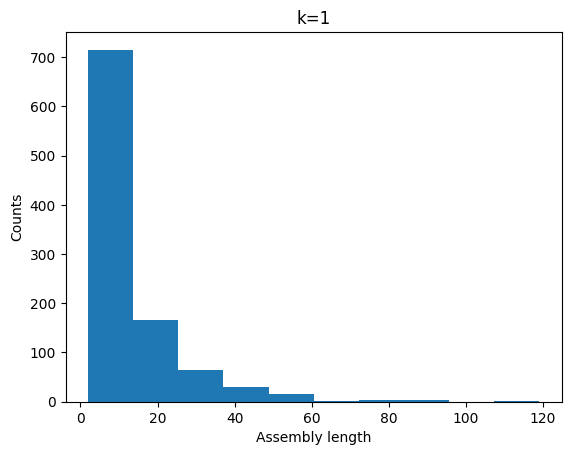

In [115]:
counts, bins = np.histogram(res[2][2])
print(counts)
print(bins)
plt.hist(bins[:-1], bins, weights=counts)
plt.xlabel("Assembly length")
plt.ylabel("Counts")
plt.title("k=1")

[536   8  27  16   3  28   2   0   0 380]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


Text(0.5, 1.0, 'k=1')

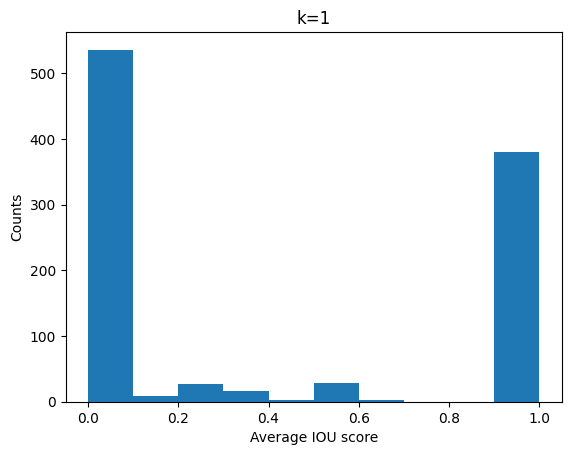

In [23]:
counts, bins = np.histogram(res[0][1])
print(counts)
print(bins)
plt.hist(bins[:-1], bins, weights=counts)
plt.xlabel("Average IOU score")
plt.ylabel("Counts")
plt.title("k=1")

In [ ]:
k = 10
for decoded_seq_dict in all_decoded_seq_list:
    ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
    ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # top k avg_dist [(aid, (seq_list, avg_dist))]
    iou = 0.0
    total_iou = 0.0
    total_iou_score = 0.0
    total_length_union = 0.0
    total = 0.0
    for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
        aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
        aid_part_graph = transform(aid_part_graph)   # map list of md --> list of idx
        c_part = seq[0]   # central part idx
        n_parts_pred = seq[1:]   # a list of neighbouring part indices
#         c_part_dup_list = search_duplicate(c_part, aid)
#         total += len(c_part_dup_list)
        max_iou = 0   # we only record the max_iou of all the sequence considering duplicates
        max_iou_score = 0
#         cur_length_union = 0
        
        # Finding duplicates for each part in the decoded seq
        dup_map = dict()
        for part_idx in seq:
            dup_map[part_idx] = search_duplicate(part_idx, aid)
            
        for c_part in dup_map[c_part]:
            if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq, otherwise max_iou stays 0
                n_parts_true = aid_part_graph[c_part][:9]
                
                iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                if iou > max_iou:
                    max_iou = iou
                if iou_score > max_iou_score:
                    max_iou_score = iou_score
#                     total_length_union += union
            else:
                iou = 0
                iou_score = 0
#         print(f'max_iou: {max_iou}')
        total_iou += max_iou   # compute 10 times
        total_iou_score += max_iou_score
    print(f'iou: {total_iou / k}, iou_score: {total_iou_score / k}')#', union length: {total_length_union/k}')

In [232]:
k = 1
for decoded_seq_dict in all_decoded_seq_list:
    ordered_decoded_seq = sorted(decoded_seq_dict.items(), key=lambda x: x[1][1])   # [(aid, (seq_list, avg_dist))]
    ordered_topk_decoded_seq = ordered_decoded_seq[:k]   # top k avg_dist [(aid, (seq_list, avg_dist))]
    iou = 0.0
    max_max_iou = 0.0
    max_max_iou_score = 0.0
    total_length_union = 0.0
    total = 0.0
    for aid, (seq, avg_dist) in ordered_topk_decoded_seq:
        aid_part_graph = all_part_graph[aid]   # obtain all the part graphs associated with aid
        aid_part_graph = transform(aid_part_graph)   # map list of md --> list of idx
        c_part = seq[0]   # central part idx
        n_parts_pred = seq[1:]   # a list of neighbouring part indices
#         c_part_dup_list = search_duplicate(c_part, aid)
#         total += len(c_part_dup_list)
        max_iou = 0   # we only record the max_iou of all the sequence considering duplicates
        max_iou_score = 0
#         cur_length_union = 0
        
        # Finding duplicates for each part in the decoded seq
        dup_map = dict()
        for part_idx in seq:
            dup_map[part_idx] = search_duplicate(part_idx, aid)
            
        for c_part in dup_map[c_part]:
            if c_part in aid_part_graph:   # if aid_part_graph contains c_part in the decoded seq, otherwise max_iou stays 0
                n_parts_true = aid_part_graph[c_part][:9]
                
                iou, iou_score = compute_iou(n_parts_pred, n_parts_true, dup_map)
                if iou > max_iou:
                    max_iou = iou
                if iou_score > max_iou_score:
                    max_iou_score = iou_score
#                     total_length_union += union
            else:
                iou = 0
                iou_score = 0
#         print(f'max_iou: {max_iou}')
        if max_iou > max_max_iou:
            max_max_iou = max_iou   # compute 10 times
        if max_iou_score > max_max_iou_score:
            max_max_iou_score = max_iou_score
    print(f'iou: {max_max_iou}, iou_score: {max_max_iou_score}')#', union length: {total_length_union/k}')

iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.399999520000576, iou_score: 0.25
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.0, iou_score: 0.0
iou: 0.0, iou_score: 0.0
iou: 0.99999950000025, iou_score: 1.0
iou: 0.49999950000050003, iou_score: 0.3333333333333333
iou: 0.0, iou_score: 0.0


# Evaluation - Display parts

In [14]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
    num_images_per_row = 50
    k = num_images_per_row*1

            
    total_num_images = len(png_paths)
    
    if k > total_num_images:
        k = total_num_images
#     chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in range(k):
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
    num_images = len(imgs)
#     sq_max = math.ceil(math.sqrt(num_images))
#     grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    grid = image_grid(imgs, 1, num_images, resize=True, texts=None)
    return grid

def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'./raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")
    
def display_single_image(image_path, resize=True):
    img = Image.open(image_path)
    if resize:
        scale = 1/3
        w, h = img.size
        newsize = (int(w*scale), int(h*scale))
        img = img.resize(newsize)
    img.show()
    
    return

In [51]:
all_decoded_seq_list[0]

[[129259, (129260, 0.06694885343313217), (129259, 0.9700649380683899)],
 [53817, (53818, 0.1551254391670227), (53812, 0.9626848697662354)],
 [55125, (55134, 0.15366125106811523), (55136, 0.9570625424385071)],
 [302, (303, 0.18007336556911469), (302, 0.9702142477035522)],
 [124397, (124386, 0.35651421546936035), (124389, 0.9646685123443604)],
 [43462, (43462, 0.37309587001800537), (43462, 0.9687010645866394)],
 [109474, (109476, 0.2601713240146637), (109471, 0.9590780138969421)],
 [93736, (93732, 0.21361574530601501), (93740, 0.9649065732955933)],
 [54639, (54648, 0.16108891367912292), (54642, 0.9612194299697876)],
 [95565, (95560, 0.1300405114889145), (95556, 0.9475212693214417)]]

## Corresponding to 2. 

In [ ]:
vid = '00'
rec_seq_idx = 2
for dec_seq_idx in range(10):
    img_md_list = []
    for img_idx in all_decoded_seq_list[rec_seq_idx][dec_seq_idx]:
        img_md = all_md[img_idx]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'Reconstructed part sequence: {rec_seq_idx}, decoded part sequence: {dec_seq_idx}', img_name_list)

## Corresponding to 1. 

## For Fusion360

Original part sequence: 39

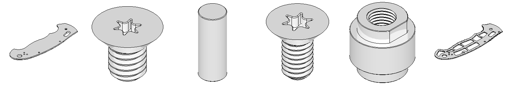

Decoded part sequence: 39

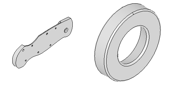

In [55]:
vid = '00'
rec_seq_idx = 39

img_md_list = []
for img_idx in all_ori_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Original part sequence: {rec_seq_idx}', img_name_list)

# vid = '00'
# rec_seq_idx = 79

img_md_list = []
for img_idx in all_rec_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Decoded part sequence: {rec_seq_idx}', img_name_list)

## For CLIP text query

Mechanism name: Double-Slider, decoded part sequence: 25

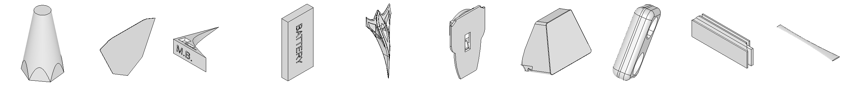

In [46]:
vid = '00'
query_seq_idx = 25
mech_names = mech_part_names['mech_name']
# part_names = mech_part_names['part_name']

img_md_list = []
for img_idx in all_query_closest_emb_list[query_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

# display_image_grid(f'Mechanism name: {mech_names[query_seq_idx]}, query: {part_names[query_seq_idx]}, decoded part sequence: {query_seq_idx}', img_name_list)
display_image_grid(f'Mechanism name: {mech_names[query_seq_idx]}, decoded part sequence: {query_seq_idx}', img_name_list)

## For ABC query

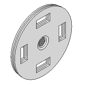

Part name: Friction rollers pair, decoded part sequence: 27

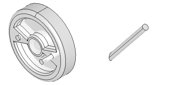

In [50]:
vid = '00'
rec_seq_idx = 27
part_name = mech_query_list[rec_seq_idx]

display_single_image(abc_md[rec_seq_idx]+'_00' + vid + '.png')

# vid = '00'
# rec_seq_idx = 79

img_md_list = []
for img_idx in all_query_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Part name: {part_name}, decoded part sequence: {rec_seq_idx}', img_name_list)

In [47]:
target = all_ori_closest_emb_list[3]

In [50]:
for res in a:
    if res[1][0][0] == target[0]:
        print(res[1][1])

## Corresponding to 3. 

parts in assembly: [133527, 133528, 133529, 133530, 133531, 133532, 133533, 133534, 133535, 133536, 133537, 133538, 133539, 133540, 133541, 133542, 133543, 133544, 133545, 133546, 133547, 133548, 133549, 133550, 133551, 133552, 133553, 133554, 133555, 133556]


decoded part sequence: 0, average distance: 0.18458817899227142, assembly id: 84374_272a9731

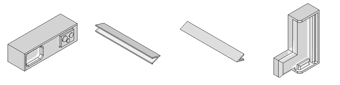

 
 
parts in assembly: [97953, 97954, 97955, 97956, 97957, 97958, 97959, 97960, 97961, 97962, 97963, 97964, 97965, 97966, 97967, 97968, 97969, 97970, 97971, 97972, 97973, 97974, 97975, 97976, 97977, 97978, 97979, 97980, 97981, 97982, 97983, 97984, 97985, 97986, 97987, 97988, 97989, 97990, 97991, 97992, 97993, 97994, 97995, 97996, 97997, 97998, 97999, 98000, 98001, 98002, 98003, 98004, 98005, 98006, 98007, 98008, 98009, 98010, 98011, 98012, 98013, 98014, 98015, 98016, 98017, 98018, 98019, 98020, 98021, 98022, 98023, 98024, 98025, 98026, 98027, 98028, 98029, 98030, 98031, 98032, 98033, 98034, 98035, 98036, 98037, 98038, 98039, 98040, 98041, 98042, 98043, 98044, 98045, 98046, 98047, 98048, 98049, 98050]


decoded part sequence: 1, average distance: 0.19145894050598145, assembly id: 43172_bebbafc3

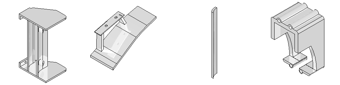

 
 
parts in assembly: [28235, 28236, 28237, 28238, 28239, 28240, 28241, 28242, 28243, 28244, 28245, 28246, 28247, 28248, 28249, 28250, 28251, 28252, 28253, 28254]


decoded part sequence: 2, average distance: 0.19337330013513565, assembly id: 136795_06c4efed

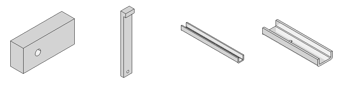

 
 
parts in assembly: [76823, 76824, 76825, 76826, 76827, 76828, 76829, 76830, 76831, 76832, 76833, 76834, 76835, 76836, 76837, 76838, 76839, 76840, 76841, 76842, 76843, 76844, 76845, 76846, 76847, 76848, 76849, 76850, 76851, 76852, 76853, 76854, 76855, 76856, 76857, 76858, 76859, 76860, 76861, 76862, 76863, 76864, 76865, 76866, 76867, 76868, 76869, 76870, 76871, 76872, 76873, 76874, 76875, 76876, 76877]


decoded part sequence: 3, average distance: 0.19350828230381012, assembly id: 31282_05c4b783

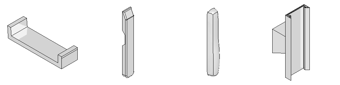

 
 
parts in assembly: [57553, 57554, 57555, 57556, 57557, 57558, 57559, 57560, 57561, 57562, 57563, 57564, 57565, 57566, 57567, 57568, 57569, 57570, 57571, 57572, 57573, 57574, 57575, 57576, 57577, 57578, 57579, 57580, 57581, 57582, 57583, 57584, 57585, 57586, 57587, 57588, 57589, 57590, 57591, 57592]


decoded part sequence: 4, average distance: 0.1936296820640564, assembly id: 23168_7fdf5427

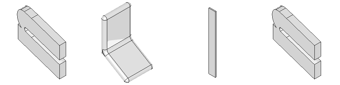

 
 
parts in assembly: [77449, 77450, 77451, 77452, 77453, 77454, 77455, 77456, 77457, 77458, 77459, 77460, 77461, 77462, 77463, 77464, 77465, 77466, 77467, 77468, 77469, 77470, 77471, 77472, 77473, 77474]


decoded part sequence: 5, average distance: 0.19398163259029388, assembly id: 31388_0d7a2c35

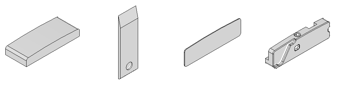

 
 
parts in assembly: [133480, 133481, 133482, 133483, 133484, 133485, 133486, 133487, 133488, 133489, 133490, 133491, 133492, 133493, 133494, 133495, 133496, 133497, 133498]


decoded part sequence: 6, average distance: 0.1952756568789482, assembly id: 84239_15bbb485

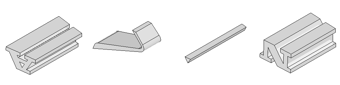

 
 
parts in assembly: [94690, 94691, 94692, 94693, 94694, 94695, 94696, 94697, 94698, 94699, 94700, 94701, 94702, 94703, 94704, 94705]


decoded part sequence: 7, average distance: 0.19598210230469704, assembly id: 41696_de0790a1

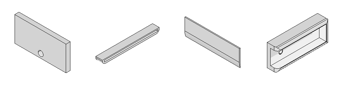

 
 
parts in assembly: [28502, 28503, 28504, 28505, 28506, 28507, 28508, 28509, 28510, 28511, 28512, 28513, 28514, 28515, 28516, 28517, 28518, 28519, 28520]


decoded part sequence: 8, average distance: 0.19856692105531693, assembly id: 136834_d1ee3f0b

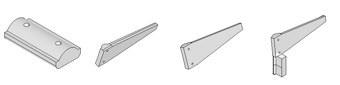

 
 
parts in assembly: [102779, 102780, 102781, 102782, 102783, 102784, 102785, 102786, 102787, 102788, 102789, 102790, 102791, 102792, 102793, 102794, 102795, 102796, 102797, 102798, 102799, 102800, 102801, 102802, 102803, 102804, 102805, 102806, 102807, 102808, 102809, 102810, 102811, 102812, 102813, 102814, 102815]


decoded part sequence: 9, average distance: 0.19880257919430733, assembly id: 49141_4dbe564e

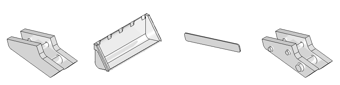

In [58]:
rec_seq_idx = 19
decoded_seq = sorted(all_decoded_seq_list[rec_seq_idx].items(), key=lambda x: x[1][1])
# print(decoded_seq[:20])

vid = '00'

img_md_list = []
for img_idx in all_ori_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Original part sequence: {rec_seq_idx}', img_name_list)

for dec_seq_idx, (aid, (indices, avg_dist)) in enumerate(decoded_seq[:10]):
    img_md_list = []
    print(f'parts in assembly: {aid_to_part_indice_map[aid]}')
    for index in indices:
        img_md = all_md[index]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'decoded part sequence: {dec_seq_idx}, average distance: {avg_dist}, assembly id: {aid}', img_name_list)

## Display the parts for a certain assembly

25


assembly id: 51859_6b2fd0f1

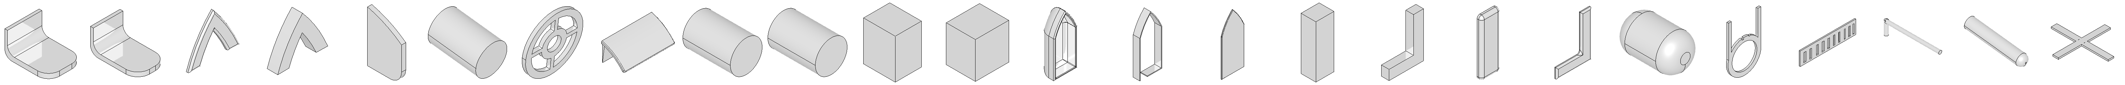

In [38]:
aid = '51859_6b2fd0f1'
indices = aid_to_part_indice_map[aid]
embs = all_emb[indices]
cdist = torch.cdist(embs, embs, p=2)
indices = torch.LongTensor(indices)
indices[torch.LongTensor((cdist[7]<1e-3).nonzero(as_tuple=True)[0])].tolist()

vid = '00'
img_md_list = []
for i, index in enumerate(indices):
    img_md = all_md[index]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)
print(len(img_name_list))

display_image_grid(f'assembly id: {aid}', img_name_list)

In [ ]:
indices

In [58]:
aid_to_part_indice_map['114349_2774708d']

[7286, 7287, 7288, 7289]